(1460, 81)
(1459, 80)
   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000
折1，训练log rmse0.142727, 验证log rmse0.179682
折2，训练log rmse0.133597, 验证log rmse0.179409
折3，训练log rmse0.137786, 验证log rmse0.172101
折4，训练log rmse0.141572, 验证log rmse0.164233
折5，训练log rmse0.132327, 验证log rmse0.177423
5-折验证: 平均训练log rmse: 0.137602, 平均验证log rmse: 0.174570
训练log rmse：0.136079


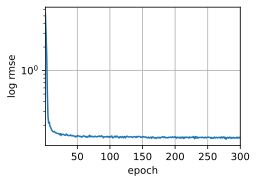

In [ ]:
import matplotlib
if not hasattr(matplotlib.RcParams, '_get'):
    matplotlib.RcParams._get = lambda self, key: self.get(key)

import hashlib
import os
import tarfile
import zipfile
import requests
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(name, cache_dir='data'):  
    """下载 DATA_HUB 中的文件，并存入指定的 data 目录"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    
    url, sha1_hash = DATA_HUB[name]
    
    # 确保 data 文件夹存在，不存在就建一个
    os.makedirs(cache_dir, exist_ok=True)
    
    # 文件路径现在会是：data/kaggle_house_pred_train.csv
    fname = os.path.join(cache_dir, url.split('/')[-1])
    
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
            
    print(f'正在从 {url} 下载至 {fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(name, folder=None): #@save
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir,ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname,'r')
    elif ext in ('.tar','.gz'):
        fp = tarfile.open(fname,'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir,folder) if folder else data_dir

def download_all():#@save
    for name in DATA_HUB:
        download(name)

DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))
print(train_data.shape)
print(test_data.shape)
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

all_features = pd.concat((train_data.iloc[:,1:-1],test_data.iloc[:,1:]))
# 总室内面积
all_features['TotalSF'] = all_features['TotalBsmtSF'] + all_features['1stFlrSF'] + all_features['2ndFlrSF']

# 房屋的新旧程度（房龄）
all_features['HouseAge'] = all_features['YrSold'] - all_features['YearBuilt']

# 总洗手间数量
all_features['TotalBath'] = (all_features['FullBath'] + (0.5 * all_features['HalfBath']) +
                              all_features['BsmtFullBath'] + (0.5 * all_features['BsmtHalfBath']))
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply( lambda x:(x-x.mean())/(x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)

all_features = pd.get_dummies(all_features,dummy_na=True)
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values,dtype = torch.float32)
test_features = torch.tensor(all_features[n_train:].values,dtype = torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),dtype = torch.float32)

loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,256),nn.ReLU(),nn.Dropout(0.2),nn.Linear(256,128),nn.ReLU(),nn.Dropout(0.2),nn.Linear(128,1))
    return net

def log_rmse(net,features,labels):
    clipped_preds = torch.clamp(net(features),1,float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),torch.log(labels)))
    return rmse.item()

def train(net, train_features, train_labels, test_features, test_labels,num_epochs, learning_rate, weight_decay, batch_size):
    train_ls,test_ls = [],[]
    train_iter = d2l.load_array((train_features,train_labels),batch_size)
    optimizer = torch.optim.Adam(net.parameters(),lr = learning_rate,weight_decay = weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
        scheduler.step()
        train_ls.append(log_rmse(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net,test_features,test_labels))
    return train_ls,test_ls

def get_k_fold_data(k,i,X,y):
    assert k > 1
    fold_size = X.shape[0]//k
    X_train,y_train = None,None
    for j in range(k):
        idx = slice(j*fold_size,(j+1)*fold_size)
        X_part,y_part = X[idx,:],y[idx]
        if j == i:
            X_valid,y_valid = X_part,y_part
        elif X_train is None: 
            X_train,y_train = X_part,y_part
        else:
            X_train = torch.cat([X_train, X_part], 0) 
            y_train = torch.cat([y_train, y_part], 0) 
            
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,batch_size):
    train_l_sum,valid_l_sum = 0,0
    for i in range(k):
        data = get_k_fold_data(k,i,X_train,y_train)
        net = get_net()
        train_ls,valid_ls = train(net, *data, num_epochs, learning_rate,weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

k, num_epochs, lr, weight_decay, batch_size = 5, 300, 0.01, 0.15, 128
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
   
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)
    

train_and_pred(train_features,test_features,train_labels,test_data,num_epochs, lr, weight_decay, batch_size)
        
    